In [1]:
!pip install torchview


In [2]:
import math
import os
import time
from datetime import timedelta
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, datasets

from torchinfo import summary
from torchview import draw_graph

import torchvision.models as models

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Dataset paths - Kaggle automatically mounts datasets
ROOT_DIR = '/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset'
TRAIN_DIR = ROOT_DIR + '/train'
TEST_DIR = ROOT_DIR + '/test'

IMG_SIZE = 224
BATCH_SIZE = 16  # Increased for better training
NUM_WORKERS = 2
RANDOM_STATE = 42
CLASSES = ["benign", "malignant"]


In [3]:
#import os
import os
for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    print(dirs)
    print('---')
##base_path = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images'
#print(os.listdir(base_path))
#print(os.listdir(base_path + '/melanoma_cancer_dataset'))

/kaggle/input
['datasets']
---
/kaggle/input/datasets
['hasnainjaved']
---
/kaggle/input/datasets/hasnainjaved
['melanoma-skin-cancer-dataset-of-10000-images']
---
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
['melanoma_cancer_dataset']
---
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset
['test', 'train']
---
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test
['benign', 'malignant']
---
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign
[]
---
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/malignant
[]
---
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train
['benign', 'malignant']
---
/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-

In [4]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load datasets
train_dataset_full = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)

print(f"Training samples: {len(train_dataset_full)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset_full.classes}")


Training samples: 9605
Test samples: 1000
Classes: ['benign', 'malignant']


In [5]:
# Create train/validation split (80/20)
train_indices, val_indices = train_test_split(
    list(range(len(train_dataset_full))), 
    test_size=0.2, 
    stratify=[label for _, label in train_dataset_full.samples],
    random_state=RANDOM_STATE
)

# Create subsets
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(train_dataset_full, val_indices)

print(f"Final training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Final training samples: 7684
Validation samples: 1921


In [6]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop


In [7]:
# Load pretrained EfficientNet-B0 model
model = models.efficientnet_b0(pretrained=True)
num_classes = 2
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

print("Model: EfficientNet-B0")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s] 


Model: EfficientNet-B0


In [8]:
# Display model summary
summary(model, input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"])

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

# Criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Using device: cuda


In [9]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)
    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()
    
    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)
    precision = precision_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    recall = recall_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    f1 = f1_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)

    # AUC calculation
    try:
        y_pred_proba = torch.softmax(y_pred, dim=1)
        y_pred_positive = y_pred_proba[:, 1].cpu().numpy()
        auc_score = roc_auc_score(y_true_numpy, y_pred_positive)
    except ValueError:
        auc_score = 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc_score,
    }
    return metrics


In [10]:
# Training configuration
num_epochs = 20
early_stopping = EarlyStopping(patience=5)
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score", "auc"]

# Metrics history
train_metrics_history = {metric: [] for metric in metric_names}
val_metrics_history = {metric: [] for metric in metric_names}

total_training_time = 0.0
total_validation_time = 0.0

print("Starting training...")
print(f"Model: {'EfficientNet-B0' if 'efficient' in str(type(model)).lower() else 'ShuffleNetV2'}")
print("=" * 60)

# Training loop with early stopping
for epoch in range(num_epochs):
    epoch_start_time = time.time()
    
    # Training phase with timing
    model.train()
    total_train_loss = 0.0
    all_train_predictions = []
    all_train_targets = []
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for batch_idx, (data, targets) in enumerate(train_pbar):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())
        
        # Update progress bar with current loss
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_training_time = time.time() - epoch_start_time
    total_training_time += epoch_training_time
    
    # Calculate training metrics
    average_train_loss = total_train_loss / len(train_loader)
    all_train_predictions = np.array(all_train_predictions)
    all_train_targets = np.array(all_train_targets)
    train_metrics = custom_metrics(torch.tensor(all_train_predictions), torch.tensor(all_train_targets), average_train_loss)
    
    # Validation phase with timing
    val_start_time = time.time()
    model.eval()
    total_val_loss = 0.0
    all_val_predictions = []
    all_val_targets = []
    
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val  ]")
    
    with torch.no_grad():
        for batch_idx, (data, targets) in enumerate(val_pbar):
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()

            all_val_predictions.extend(outputs.detach().cpu().numpy())
            all_val_targets.extend(targets.detach().cpu().numpy())
            
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    val_time = time.time() - val_start_time
    total_validation_time += val_time
    
    # Calculate validation metrics
    average_val_loss = total_val_loss / len(val_loader)
    all_val_predictions = np.array(all_val_predictions)
    all_val_targets = np.array(all_val_targets)
    val_metrics = custom_metrics(torch.tensor(all_val_predictions), torch.tensor(all_val_targets), average_val_loss)
    
    # Store metrics
    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])
        val_metrics_history[metric].append(val_metrics[metric])
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} Summary:")
    print(f"  Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}")
    print(f"  Val   Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}")
    print(f"  Times - Train: {str(timedelta(seconds=epoch_training_time))[:-7]}, "
          f"Val: {str(timedelta(seconds=val_time))[:-7]}")
    
    # Check early stopping
    if early_stopping(val_metrics['loss']):
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print("=" * 60)
print(f"Total Training Time: {str(timedelta(seconds=total_training_time))[:-7]}")
print(f"Total Validation Time: {str(timedelta(seconds=total_validation_time))[:-7]}")


Starting training...
Model: EfficientNet-B0


Epoch 1/20 [Val  ]: 100%|██████████| 121/121 [00:12<00:00,  9.57it/s, loss=0.0005]


Epoch 1/20 Summary:
  Train Loss: 0.2846, Acc: 0.8893
  Val   Loss: 0.2335, Acc: 0.9131
  Times - Train: 0:00:50, Val: 0:00:12


Epoch 2/20 [Val  ]: 100%|██████████| 121/121 [00:05<00:00, 23.99it/s, loss=0.0001]


Epoch 2/20 Summary:
  Train Loss: 0.2035, Acc: 0.9218
  Val   Loss: 0.1799, Acc: 0.9370
  Times - Train: 0:00:38, Val: 0:00:05


...

Epoch 6/20 Summary:
  Train Loss: 0.1296, Acc: 0.9513
  Val   Loss: 0.2425, Acc: 0.8959
  Times - Train: 0:00:41, Val: 0:00:05


Epoch 7/20 [Val  ]: 100%|██████████| 121/121 [00:05<00:00, 21.21it/s, loss=0.0000]


Epoch 7/20 Summary:
  Train Loss: 0.1263, Acc: 0.9529
  Val   Loss: 0.2138, Acc: 0.9287
  Times - Train: 0:00:41, Val: 0:00:05


Epoch 8/20 [Val  ]: 100%|██████████| 121/121 [00:05<00:00, 21.17it/s, loss=0.0005]

Epoch 8/20 Summary:
  Train Loss: 0.1138, Acc: 0.9560
  Val   Loss: 0.2031, Acc: 0.9209
  Times - Train: 0:00:41, Val: 0:00:05
Early stopping triggered at epoch 8
Total Training Time: 0:05:34
Total Validation Time: 0:00:50


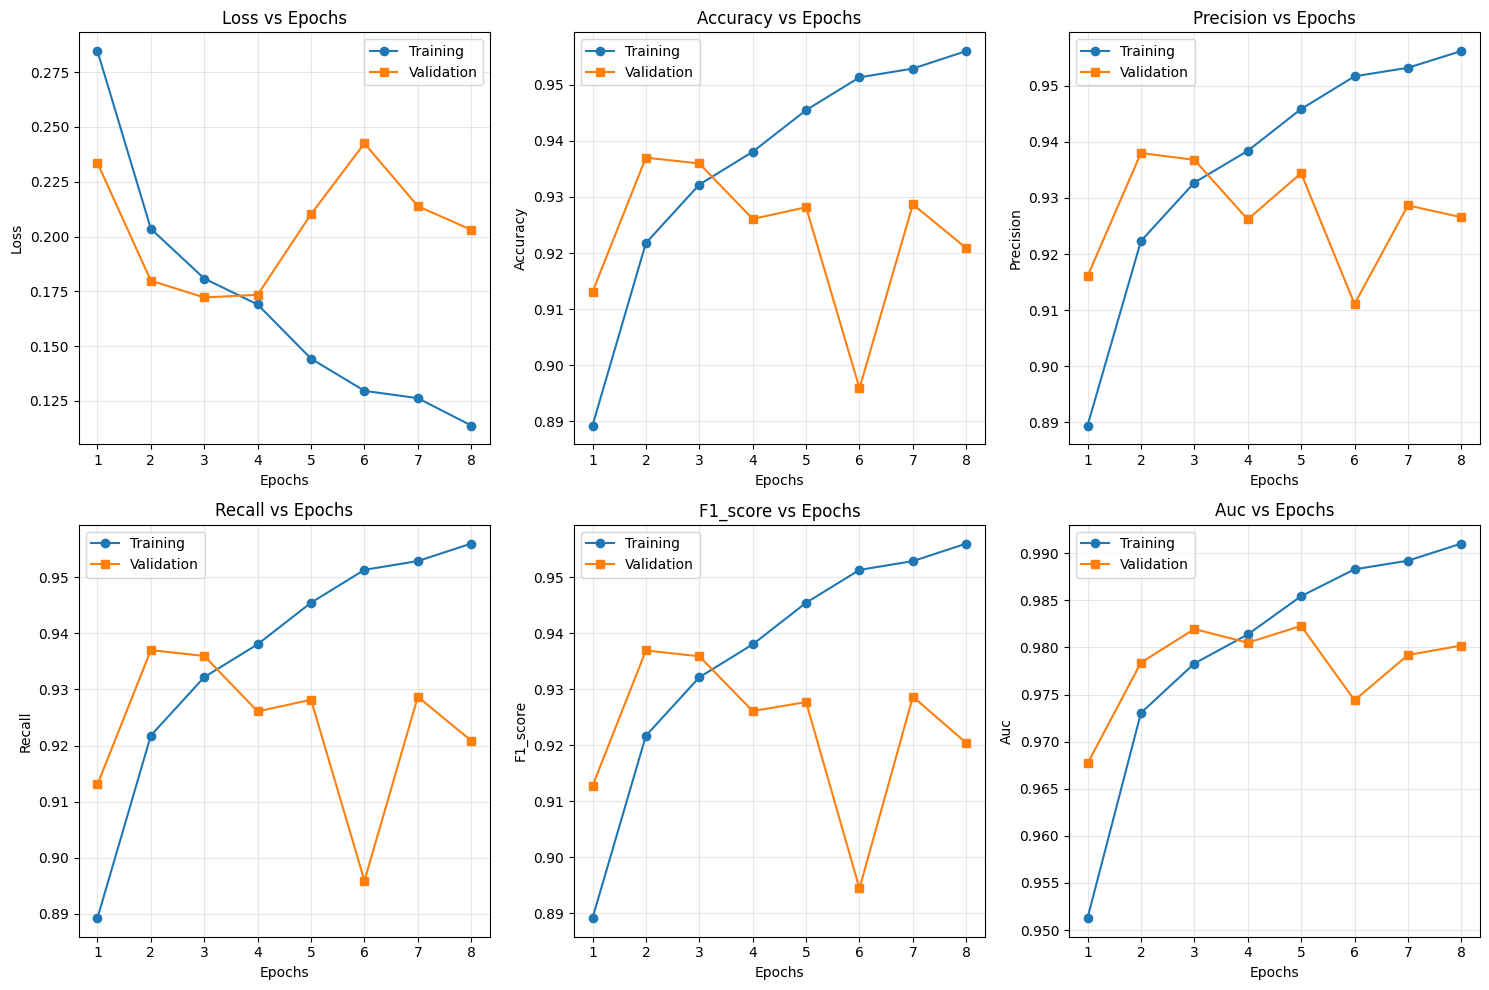

In [11]:
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    rng = range(1, num_epochs + 1)

    for i, metric_name in enumerate(metric_names):
        if i < len(axes):
            ax = axes[i]
            train_metric = train_metrics_history[metric_name]
            val_metric = val_metrics_history[metric_name]

            ax.plot(rng, train_metric, label="Training", marker='o')
            ax.plot(rng, val_metric, label="Validation", marker='s')
            ax.legend()
            ax.set_xlabel("Epochs")
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")
            ax.grid(True, alpha=0.3)

    # Hide unused subplot
    if len(metric_names) < len(axes):
        for i in range(len(metric_names), len(axes)):
            axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Plot the metrics
plot_metrics(train_metrics_history, val_metrics_history, metric_names)


In [12]:
# Final testing on test set
model.eval()
total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

test_pbar = tqdm(test_loader, desc="Testing")

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(test_pbar):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.detach().cpu().numpy())
        all_test_targets.extend(targets.detach().cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)
test_metrics = custom_metrics(torch.tensor(all_test_predictions), torch.tensor(all_test_targets), average_test_loss)

print("FINAL TEST RESULTS:")
print("=" * 30)
for metric, value in test_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")


Testing: 100%|██████████| 63/63 [00:07<00:00,  8.05it/s]

FINAL TEST RESULTS:
Loss: 0.2629
Accuracy: 0.9130
Precision: 0.9220
Recall: 0.9130
F1_score: 0.9125
Auc: 0.9759


In [13]:
# Save the trained model
model_name = 'efficientnet_b0' if 'efficient' in str(type(model)).lower() else 'shufflenet_v2'
torch.save(model.state_dict(), f'{model_name}_melanoma_classifier.pth')
print(f"Model saved as '{model_name}_melanoma_classifier.pth'")

# Create results summary
results_df = pd.DataFrame({
    'Metric': list(test_metrics.keys()),
    'Value': list(test_metrics.values())
})
print("\nResults Summary:")
print(results_df)


Model saved as 'efficientnet_b0_melanoma_classifier.pth'

Results Summary:
      Metric     Value
0       loss  0.262912
1   accuracy  0.913000
2  precision  0.921995
3     recall  0.913000
4   f1_score  0.912534
5        auc  0.975892
